## Group: PNH2
#### Members: Hong Son, Zi Ting, Nitesh, Minh

#### Dataset from Kaggle : "Titanic - Machine Learning from Disaster"
#### Source: https://www.kaggle.com/competitions/titanic/overview

---

### Essential Libraries

Let us begin by importing the essential Python Libraries.

- NumPy : Library for Numeric Computations in Python
- Pandas : Library for Data Acquisition and Preparation
- Seaborn : Higher-level library for Data Visualization
- Matplotlib : Low-level library for Data Visualization
- Scipy: Provides algorithms for optimization, integration, interpolation, eigenvalue problems, algebraic equations, differential equations, statistics
- Sklearn: Efficient tool for Predictive Data Analysis
- Shap: Shows the Importance of Predictor Variables
- Joblib: To Store Decision Tree Models

### Data Dictionary
<div style="display: inline-block">
    
|Variable|Definition|Key|
|:-------|:---------|:---|
|survival|Survival|0 = No, 1 = Yes|
|pclass  |Ticket class|1 = 1st, 2 = 2nd, 3 = 3rd|
|sex     |Sex|	
|Age     |Age in years|	
|sibsp   |# of siblings / spouses aboard the Titanic|	
|parch	 |# of parents / children aboard the Titanic|
|ticket	 |Ticket number|
|fare	 |Passenger fare|
|cabin	 |Cabin number|
|embarked|Port of Embarkation|C = Cherbourg, Q = Queenstown, S = Southampton|

</div>

---
### If the below code does not run, Run the following code in `Anaconda Prompt`
pip install numpy <br>
pip install pandas <br>
pip install seaborn <br>
pip install matplotlib <br>
pip install scipy <br>
pip install scikit-learn <br>
pip install graphviz <br>
pip install IPython <br>
pip install shap <br>
pip install joblib <br>


In [26]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt                            # Only require pyplot
from scipy.stats import chi2_contingency                   # For Cramer's V correlation formula
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import graphviz as gp
from IPython.display import SVG, display, HTML
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')
sb.set() 

---

### Import the Dataset

##### The Titanic dataset is in CSV format; Use the read_csv function from Pandas.
##### Immediately after importing, take a quick look at the data using the head() function.

In [27]:
data = pd.read_csv("train.csv")
data = pd.DataFrame(data)
print(data.shape)

# Display the first and last few rows of the data
pd.concat([data.head(n=5), data.tail(n=5)])

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q


### Size & Data Types of Train Set
- Check the vital statistics of the dataset using the `type` and `shape` attributes.
- Check the variables (and their types) in the dataset using the `dtypes` attribute.

In [28]:
print("Data type : ", type(data))
print("Data dims : ", data.shape)

Data type :  <class 'pandas.core.frame.DataFrame'>
Data dims :  (891, 12)


In [29]:
print(data.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


### Summary Statistics of Train Set
Using `describe()` function

In [30]:
data.describe(include = "all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


### Check For Null Values in Train Set
Using `isnull()` and `sum()` functions

In [31]:
print(pd.isnull(data).sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


#### Conclusion: Age and Cabin have null values.

---
### Visualisation of Survivability (Piechart)
Using `plt.pie()` function

Survived
0           549
1           342
Name: count, dtype: int64


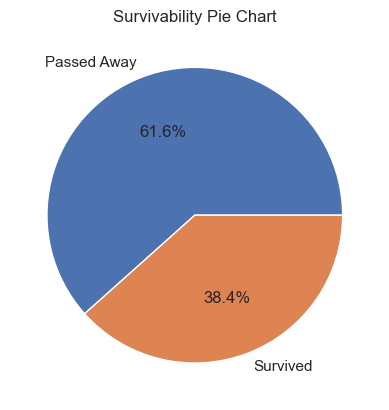

In [32]:
survived = pd.DataFrame(data['Survived'])
print(survived.value_counts())
plt.pie(
    survived.value_counts(),
    labels=['Passed Away', 'Survived'],
    autopct='%1.1f%%',
)
# Survivability Piechart
plt.title("Survivability Pie Chart")
plt.show()

---
## Exploratory Analysis between Age & Survivability

---
### Age Histogram
Shows the distribution of `Age` ranging from **0 to 80**

Text(0.5, 1.0, 'Age Histogram')

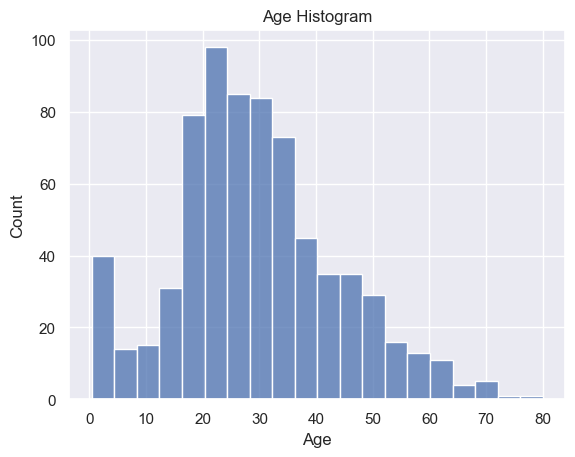

In [33]:
sb.histplot(data = data["Age"])
plt.title("Age Histogram")

---
### Box Plot & Swarmplot of Survived against Age

<Axes: xlabel='Age', ylabel='Survived'>

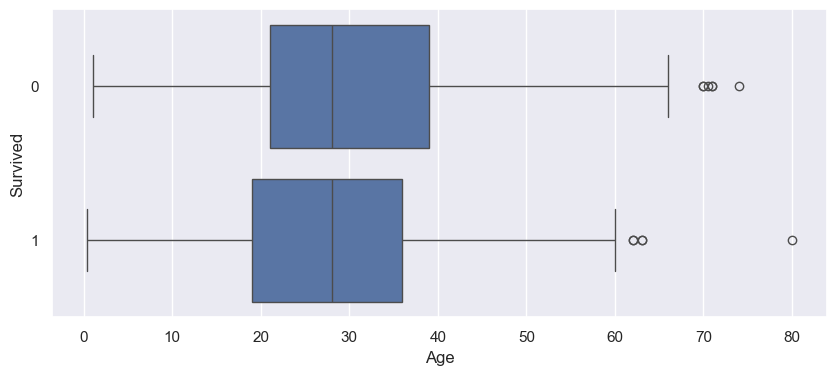

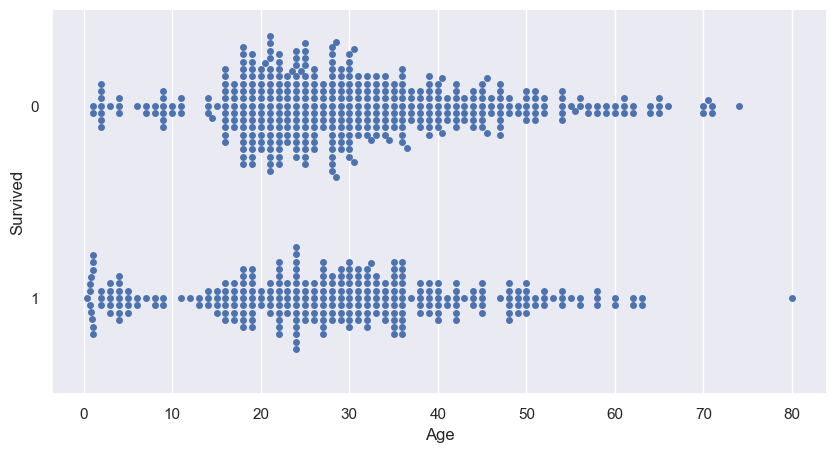

In [34]:
jointAge = pd.concat([survived, data["Age"]], axis = 1)

# Joint Boxplot of Age against Surivival
f = plt.figure(figsize=(10, 4))
sb.boxplot(x = "Age", y = "Survived", data = jointAge, orient = "h")

# Joint Swarmplot of Age against Surivival
f = plt.figure(figsize=(10, 5))
sb.swarmplot(x = "Age", y = "Survived", data = jointAge, orient = "h")

#### Based on the boxplot & swarmplot
&rarr;There is `no clear line` to indicate which portion of age is surviving or dying. <br>
&rarr;Age has a `very weak relationship` with Survivability.

---
### Correlation between Age & Survivability (Heatmap)
`.corr()` generates the Pearson Correlation Coefficient. 

<Axes: >

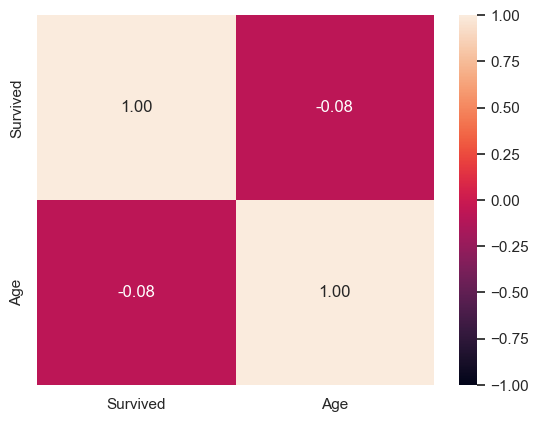

In [35]:
sb.heatmap(jointAge.corr(), vmin = -1, vmax = 1, annot = True, fmt=".2f")

**Scale (-1 to +1)** <br>
    +1.0 --> Perfect Positive Correlation (If A up, B up) <br>
    0.0  --> No Correlation (Random noise) <br>
    -1.0 --> Perfect Negative Correlation (If A up, B down) <br>

**Correlation = -0.08** <br>
&rarr;Age has a `very weak negative linear relationship` with Survivability

---
## Exploratory Analysis between Pclass & Survivability

---
### Pclass(Ticket Class) Pie Chart
Using `plt.pie()` function

Pclass
3         491
1         216
2         184
Name: count, dtype: int64


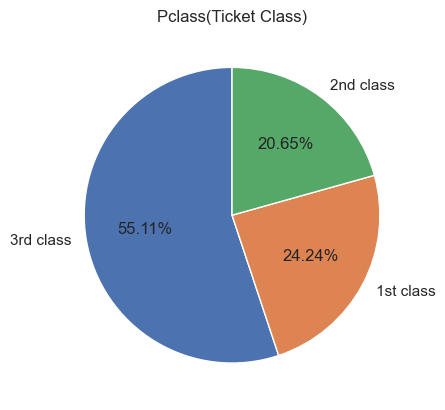

In [36]:
Pclass = pd.DataFrame(data['Pclass'])
print(Pclass.value_counts())
plt.pie(
    Pclass.value_counts(), 
    labels = ["3rd class", "1st class", "2nd class"], 
    autopct='%1.2f%%',
    startangle = 90
)
plt.title("Pclass(Ticket Class)")
plt.show()

---
### Bar Graph of Survivability for Each Pclass

Text(0, 0.5, 'Survivability')

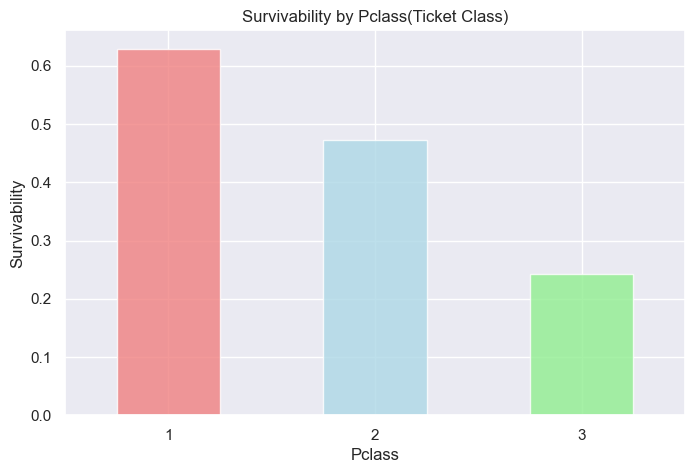

In [37]:
class_rate = data.groupby("Pclass")["Survived"].mean()
ax = class_rate.plot(
    kind="bar",
    color=["lightcoral", "lightblue", "lightgreen"],
    alpha=0.8,
    figsize=(8, 5),
    rot=0
)
plt.title("Survivability by Pclass(Ticket Class)")
plt.ylabel('Survivability')

In [38]:
print(class_rate)

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


<div style="display: inline-block">

|Pclass|Survivability|
|------|-------------|
|1st Class|~63%|
|2nd Class|~47%|
|3rd Class|~24%|

</div>

---
### Correlation between Pclass & Survivability using Cramer's V Formula
**Cramer's V Formula**
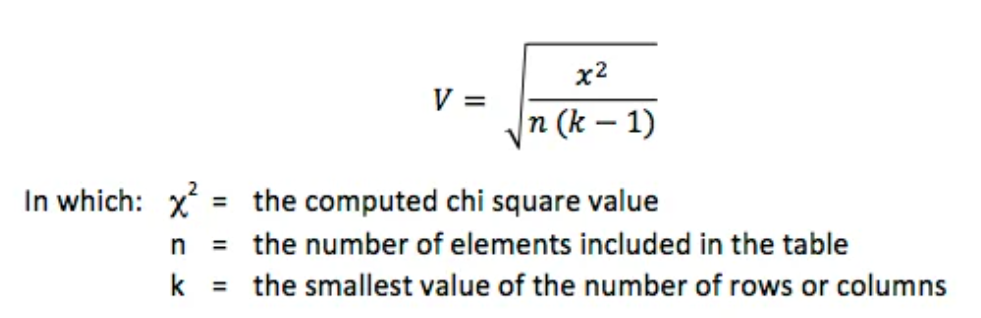

In [39]:
from scipy.stats import chi2_contingency

jointClass = pd.concat([survived, Pclass], axis = 1)

# Function to calculate Cramer's V
def cramers_v(var1, var2):
    crosstab = pd.crosstab(var1, var2)                               # Create contingency table of var1/2
    chi2 = chi2_contingency(crosstab)[0]                             # Calculate x^2
    n = crosstab.sum().sum()                                         # n = Total Number of Observations
    return np.sqrt(chi2 / (n * (min(crosstab.shape) - 1)))           # Cramer's V Formula

# Calculate correlation
correlation = cramers_v(jointClass["Survived"], jointClass["Pclass"])
print(f"Cramér's V: {correlation}")

Cramér's V: 0.33981738800531175


**Scale (0 to 1)** <br>
    1.0 --> Perfect Correlation <br>
    0.0  --> No Correlation (Random noise) <br>

**Correlation = 0.34** <br>
&rarr;Pclass has a `weak relationship` with Survivability

---
## Exploratory Analysis between Fare & Survivability

---
### Box Plot & Swarmplot of Survived against Fare

     Survived     Fare
0           0   7.2500
1           1  71.2833
2           1   7.9250
3           1  53.1000
4           0   8.0500
..        ...      ...
886         0  13.0000
887         1  30.0000
888         0  23.4500
889         1  30.0000
890         0   7.7500

[891 rows x 2 columns]


<Axes: xlabel='Fare', ylabel='Survived'>

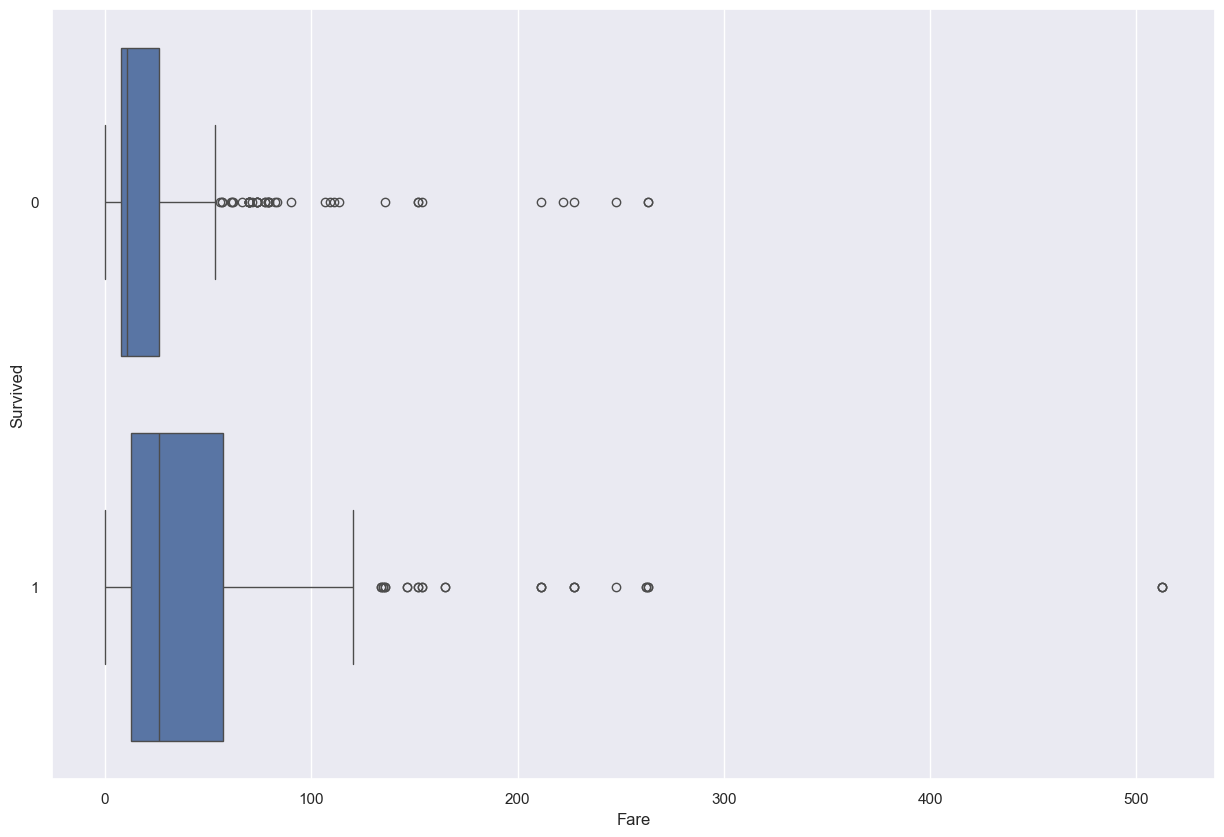

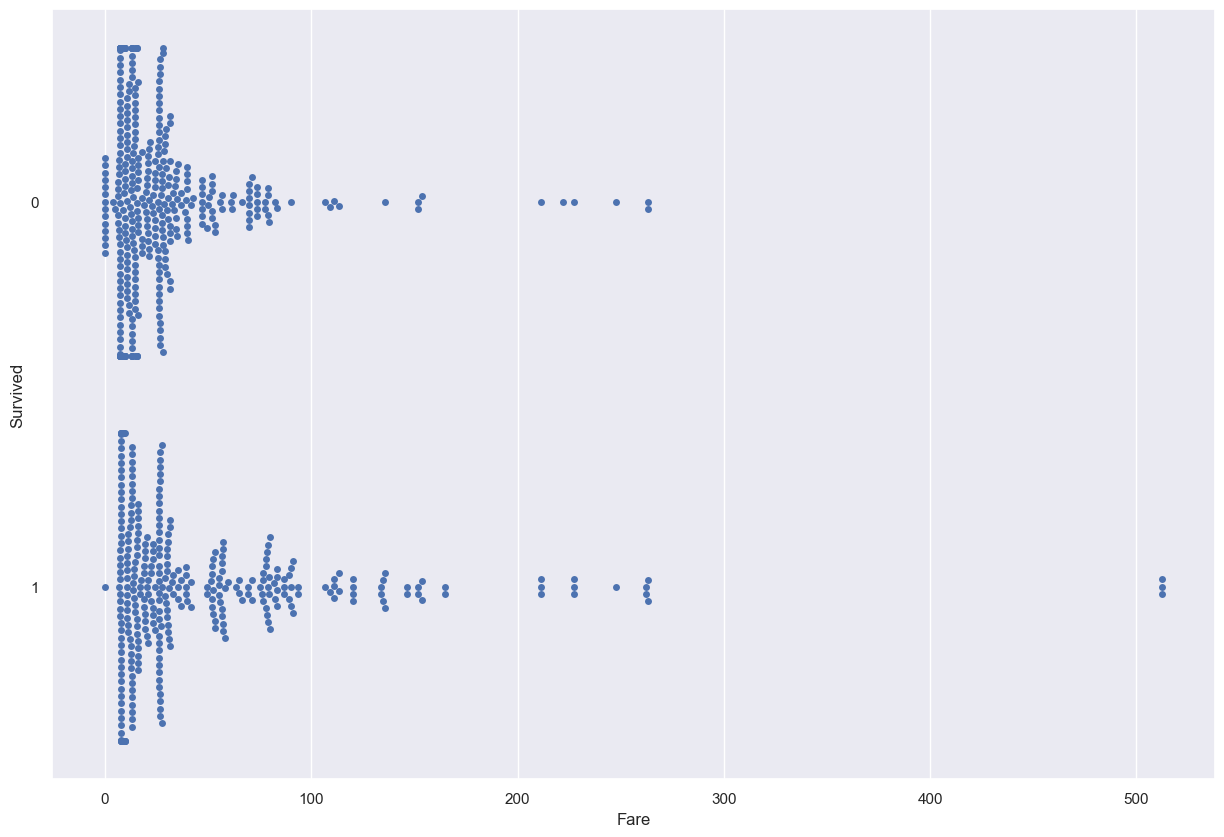

In [40]:
jointFare = pd.DataFrame(data[["Survived","Fare"]])
print(jointFare)

plt.rcParams.update({'figure.max_open_warning': 0})

# Joint Boxplot of Fare against Surivival
f = plt.figure(figsize=(15, 10))
sb.boxplot(x = "Fare", y = "Survived", data = jointFare, orient = "h")

# Joint Swarmplot of Fare against Surivival
f = plt.figure(figsize=(15, 10))
sb.swarmplot(x = "Fare", y = "Survived", data = jointFare, orient = "h")

#### Based on the boxplot & swarmplot
&rarr;There is `no clear line` to indicate which portion of fare is surviving or dying. <br>
&rarr;Fare has a `weak relationship` with Survivability.

<Axes: >

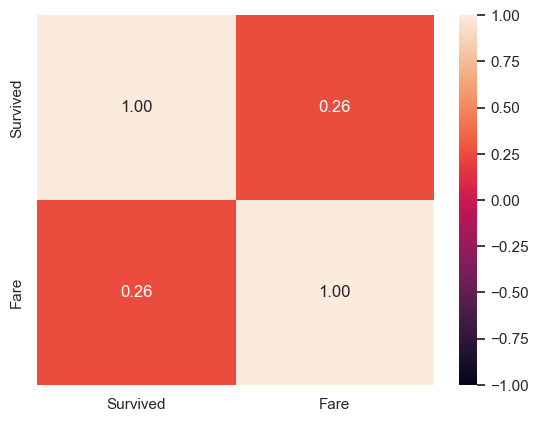

In [41]:
sb.heatmap(jointFare.corr(), vmin = -1, vmax = 1, annot = True, fmt=".2f")

**Scale (-1 to +1)** <br>
    +1.0 --> Perfect Positive Correlation (If A up, B up) <br>
    0.0  --> No Correlation (Random noise) <br>
    -1.0 --> Perfect Negative Correlation (If A up, B down) <br>

**Correlation = 0.26** <br>
&rarr;Fare has a `weak positive linear relationship` with Survivability

---
## Exploratory Analysis between Sex & Survivability

---
### Piechart of Sex

Sex   
male      577
female    314
Name: count, dtype: int64


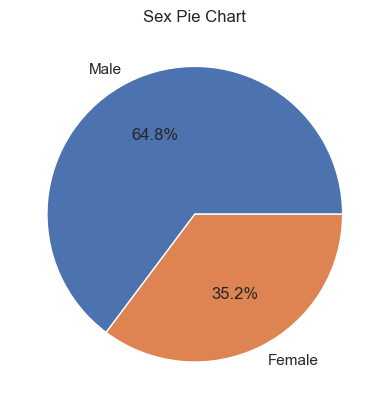

In [42]:
sex = pd.DataFrame(data['Sex'])
print(sex.value_counts())
plt.pie(
    sex.value_counts(),
    labels=['Male', 'Female'],
    autopct='%1.1f%%',
)
# Survivability Piechart
plt.title("Sex Pie Chart")
plt.show()

---
### Bar Graph of Survivability for Each Sex

Text(0, 0.5, 'Survivability')

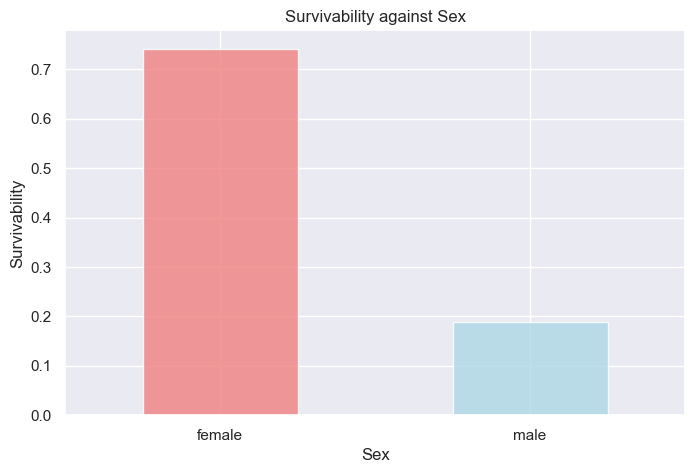

In [43]:
gender_rate = data.groupby("Sex")["Survived"].mean()
ax = gender_rate.plot(
    kind="bar",
    color=["lightcoral", "lightblue"],
    alpha=0.8,
    figsize=(8, 5),
    rot=0
)
plt.title("Survivability against Sex")
plt.ylabel('Survivability')

In [44]:
print(gender_rate)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


<div style="display: inline-block">

|Sex|Survivability|
|------|-------------|
|Female|~74%|
|Male|~19%|
</div>

---
### Correlation between Sex & Survivability using Cramer's V Formula

In [45]:
from scipy.stats import chi2_contingency

jointsex = pd.concat([survived, data["Sex"]], axis = 1)
print(jointsex)

# Function to calculate Cramer's V
def cramers_v(var1, var2):
    crosstab = pd.crosstab(var1, var2)                               # Create contingency table of var1/2
    chi2 = chi2_contingency(crosstab)[0]                             # Calculate x^2
    n = crosstab.sum().sum()                                         # n = Total Number of Observations
    return np.sqrt(chi2 / (n * (min(crosstab.shape) - 1)))           # Cramer's V Formula

# Calculate correlation
correlation = cramers_v(jointsex["Survived"], jointsex["Sex"])
print(f"Cramér's V: {correlation}")

     Survived     Sex
0           0    male
1           1  female
2           1  female
3           1  female
4           0    male
..        ...     ...
886         0    male
887         1  female
888         0  female
889         1    male
890         0    male

[891 rows x 2 columns]
Cramér's V: 0.5409359434469282


**Scale (0 to 1)** <br>
    1.0 --> Perfect Correlation <br>
    0.0  --> No Correlation (Random noise) <br>

**Correlation = 0.54** <br>
&rarr;Sex has a `moderate relationship` with Survivability

---
## Exploratory Analysis between SibSp & Survivability

---
### Pie Chart of SibSp (Number of Siblings/Spouse onboard)

SibSp
0        608
1        209
2         28
4         18
3         16
8          7
5          5
Name: count, dtype: int64


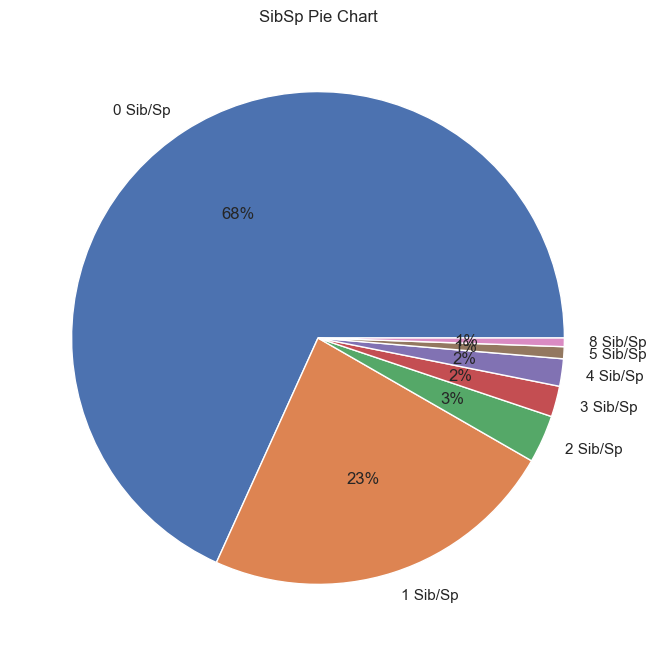

In [46]:
sibsp = pd.DataFrame(data['SibSp'])
print(sibsp.value_counts())
plt.figure(figsize=(10,8))
plt.pie(
    sibsp.value_counts(),
    labels=['0 Sib/Sp', '1 Sib/Sp', '2 Sib/Sp', '3 Sib/Sp', '4 Sib/Sp', '5 Sib/Sp', '8 Sib/Sp'],
    autopct='%1.0f%%',
)
# Survivability Piechart
plt.title("SibSp Pie Chart")
plt.show()

---
### Bar Graph of Survivability for Number of Siblings/Spouse

Text(0, 0.5, 'Survivability')

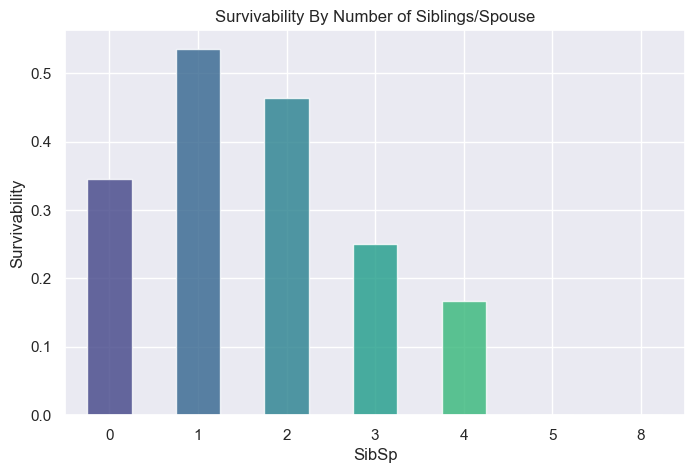

In [47]:
sib_rate = data.groupby("SibSp")["Survived"].mean()
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(sib_rate)))  
ax = sib_rate.plot(
    kind="bar",
    color=colors,
    alpha=0.8,
    figsize=(8, 5),
    rot=0
)
plt.title("Survivability By Number of Siblings/Spouse")
plt.ylabel('Survivability')

In [48]:
print(sib_rate)

SibSp
0    0.345395
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: Survived, dtype: float64


<div style="display: inline-block">

|SibSp|Survivability|
|------|-------------|
|0|~34%|
|1|~53%|
|2|~46%|
|3|~25%|
|4|~16%|
|5|0%|
|8|0%|
</div>

---
### Correlation between SibSp & Survivability using Cramer's V Formula

In [49]:
jointSib = pd.concat([data['SibSp'], data['Survived']],axis = 1)

# Function to calculate Cramer's V
def cramers_v(var1, var2):
    crosstab = pd.crosstab(var1, var2)                               # Create contingency table of var1/2
    chi2 = chi2_contingency(crosstab)[0]                             # Calculate x^2
    n = crosstab.sum().sum()                                         # n = Total Number of Observations
    return np.sqrt(chi2 / (n * (min(crosstab.shape) - 1)))           # Cramer's V Formula

# Calculate correlation
correlation = cramers_v(data['SibSp'], data['Survived'])
print(f"Cramér's V: {correlation}")

Cramér's V: 0.2045273023663305


**Scale (0 to 1)** <br>
    1.0 --> Perfect Correlation <br>
    0.0  --> No Correlation (Random noise) <br>

**Correlation = 0.2** <br>
&rarr;SibSp has a `weak relationship` with Survivability

---
## Exploratory Analysis between Parch & Survivability

---
### Pie Chart of Parch (Number of Parents/Children on board)

SibSp
0        608
1        209
2         28
4         18
3         16
8          7
5          5
Name: count, dtype: int64


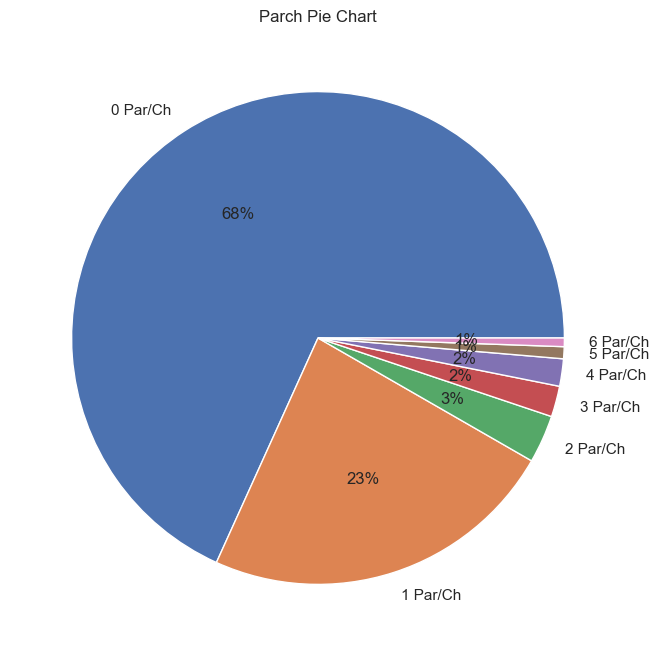

In [50]:
parch = pd.DataFrame(data['SibSp'])
print(parch.value_counts())
plt.figure(figsize=(10,8))
plt.pie(
    sibsp.value_counts(),
    labels=['0 Par/Ch', '1 Par/Ch', '2 Par/Ch', '3 Par/Ch', '4 Par/Ch', '5 Par/Ch', '6 Par/Ch'],
    autopct='%1.0f%%',
)
# Survivability Piechart
plt.title("Parch Pie Chart")
plt.show()

---
### Bar Graph of Survivability for Number of Parents/Children (Parch)

Text(0, 0.5, 'Survivability')

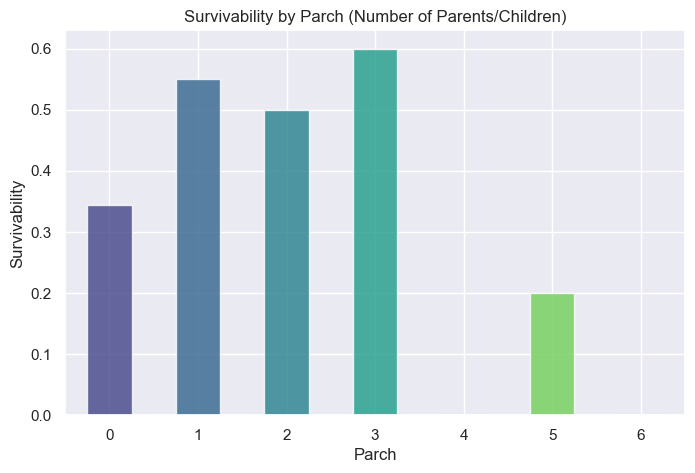

In [51]:
parch_rate = data.groupby("Parch")["Survived"].mean()
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(parch_rate)))
ax = parch_rate.plot(
    kind="bar",
    color=colors,
    alpha=0.8,
    figsize=(8, 5),
    rot=0
)
plt.title("Survivability by Parch (Number of Parents/Children)")
plt.ylabel('Survivability')

In [52]:
print(parch_rate)

Parch
0    0.343658
1    0.550847
2    0.500000
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: Survived, dtype: float64


<div style="display: inline-block">

|Parch|Survivability|
|------|-------------|
|0|~34%|
|1|~55%|
|2|~50%|
|3|~60%|
|4|0%|
|5|20%|
|8|0%|
</div>

---
### Correlation between Parch & Survivability using Cramer's V Formula

In [53]:
from scipy.stats import chi2_contingency

jointParch = pd.concat([survived, data['Parch']], axis = 1)

# Function to calculate Cramer's V
def cramers_v(var1, var2):
    crosstab = pd.crosstab(var1, var2)                               # Create contingency table of var1/2
    chi2 = chi2_contingency(crosstab)[0]                             # Calculate x^2
    n = crosstab.sum().sum()                                         # n = Total Number of Observations
    return np.sqrt(chi2 / (n * (min(crosstab.shape) - 1)))           # Cramer's V Formula

# Calculate correlation
correlation = cramers_v(jointParch["Survived"], jointParch["Parch"])
print(f"Cramér's V: {correlation}")

Cramér's V: 0.177036916072161


**Scale (0 to 1)** <br>
    1.0 --> Perfect Correlation <br>
    0.0  --> No Correlation (Random noise) <br>

**Correlation = 0.17** <br>
&rarr;Parch has a `very weak relationship` with Survivability

---
## Exploratory Analysis between Age Groups & Survivability

---
### Clustering Ages into Age Groups
`.fillna(-0.5)` fills up all the NA values with -0.5 <br>
**Bin edges**: `[-1,0)`, `[0,5)`, `[5,12)`, `[12,18)`, `[18,24)`, `[24,35)`, `[35,60)`, `[60,∞)` <br>
**Age Groups**: `Unknown`, `Baby`, `Child`, `Teenager`, `Student`, `Young Adult`, `Adult`, `Senior`

In [54]:
data["Age"] = data["Age"].fillna(-0.5)

bins = [-1, 0, 5, 12, 18, 24, 35, 60, np.inf]
labels = ['Unknown', 'Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Senior']

data["Age Group"] = pd.cut(data["Age"], bins, labels = labels)

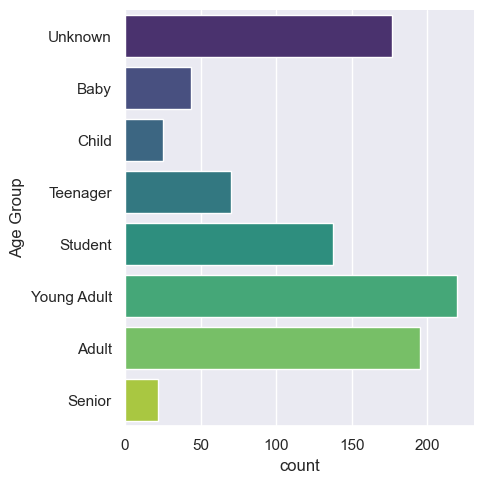

In [55]:
sb.catplot(
    y="Age Group",
    data=data,
    kind="count",
    hue = "Age Group",
    palette="viridis",
    legend = False
)

#### Conclusion: Majority of the passengers are Students, Young Adults, Adults and Unknown Age Group.

---
### Bar Graph of Survivability for Age Groups

Text(0.5, 0, 'Survivability')

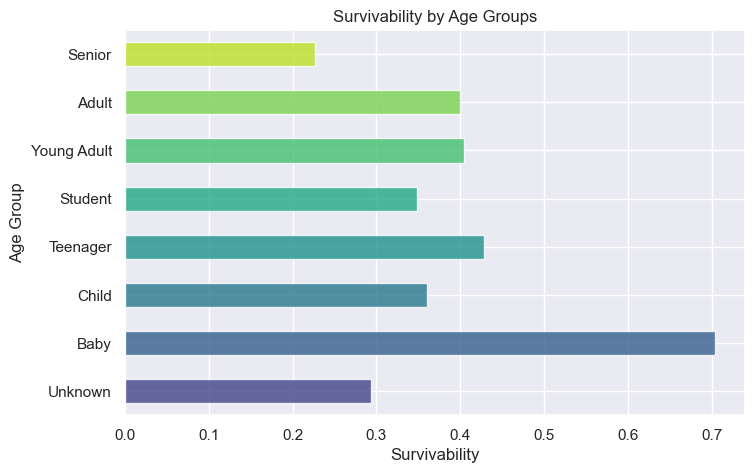

In [56]:
agegroup_rate = data.groupby("Age Group", observed=False)["Survived"].mean()
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(agegroup_rate)))
ax = agegroup_rate.plot(
    kind="barh",
    color=colors,
    alpha=0.8,
    figsize=(8, 5),
    rot=0
)
plt.title("Survivability by Age Groups")
plt.xlabel('Survivability')

In [57]:
print(agegroup_rate)

Age Group
Unknown        0.293785
Baby           0.704545
Child          0.360000
Teenager       0.428571
Student        0.347826
Young Adult    0.404545
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


<div style="display: inline-block">

|Age Group|Survivability|
|------|-------------|
|Unknown|~29%|
|Baby|~70%|
|Child|~36%|
|Teenager|~42%|
|Student|~34%|
|Young Adult|~40%|
|Adult|~40%|
|Senior|~22%|
</div>

#### Conclusion: Babies and Teenagers have a higher chance of surviving compared to the other age groups.

---
### Correlation between Age Groups & Survivability using Cramer's V Formula

In [58]:
jointagegroup = pd.concat([data["Age Group"], data['Survived']],axis = 1)

# Function to calculate Cramer's V
def cramers_v(var1, var2):
    crosstab = pd.crosstab(var1, var2)                               # Create contingency table of var1/2
    chi2 = chi2_contingency(crosstab)[0]                             # Calculate x^2
    n = crosstab.sum().sum()                                         # n = Total Number of Observations
    return np.sqrt(chi2 / (n * (min(crosstab.shape) - 1)))           # Cramer's V Formula

# Calculate correlation
correlation = cramers_v(data["Age Group"], data['Survived'])
print(f"Cramér's V: {correlation}")

Cramér's V: 0.18198164188116212


**Scale (0 to 1)** <br>
    1.0 --> Perfect Correlation <br>
    0.0  --> No Correlation (Random noise) <br>

**Correlation = 0.18** <br>
&rarr;Age Groups has a `weak relationship` with Survivability

---
## Exploratory Analysis between CabinBool & Survivability

---
### Pie Chart of CabinBool (1 = Have Cabin Booked, 0 = Have No Cabin)

CabinBool
0    687
1    204
Name: count, dtype: int64


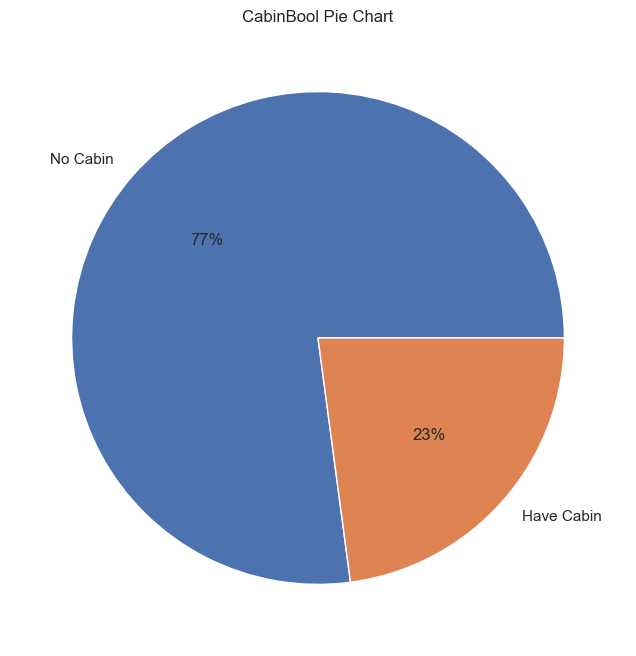

In [59]:
data["CabinBool"] = (data["Cabin"].notnull().astype('int'))
cabinbool = data["CabinBool"]
print(cabinbool.value_counts())
plt.figure(figsize=(10,8))
plt.pie(
    cabinbool.value_counts(),
    labels=['No Cabin', 'Have Cabin'],
    autopct='%1.0f%%',
)
# Survivability Piechart
plt.title("CabinBool Pie Chart")
plt.show()

---
### Bar Graph of Survivability for People with Cabin Bookings
`notnull()` returns **True** if the value is **not null (NaN)** and **False** if it is **null**. <br> 
`astype('int')` converts boolean values **(True/False)** to integers **(1/0)**

Text(0, 0.5, 'Survivability')

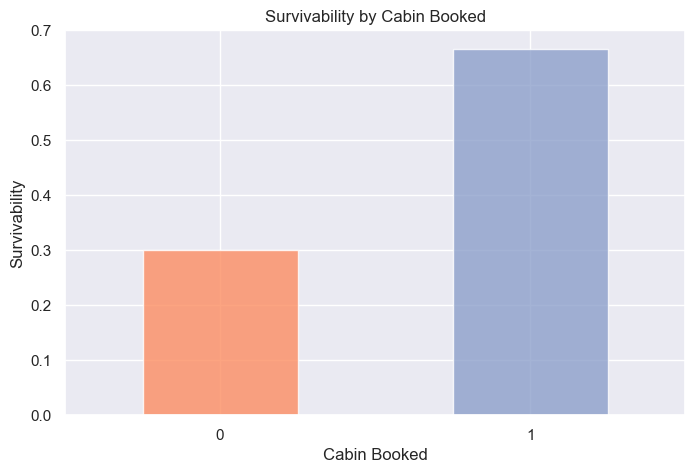

In [60]:
cabin_rate = data.groupby("CabinBool")["Survived"].mean()
colors = plt.cm.Set2(np.linspace(0.2, 0.9, len(agegroup_rate)))
ax = cabin_rate.plot(
    kind="bar",
    color=colors,
    alpha=0.8,
    figsize=(8, 5),
    rot=0
)
plt.title("Survivability by Cabin Booked")
plt.xlabel('Cabin Booked')
plt.ylabel('Survivability')

##The idea is when a person have cabin data, they are more likely to have better social status/records => better survivability

In [61]:
print(cabin_rate)

CabinBool
0    0.299854
1    0.666667
Name: Survived, dtype: float64


<div style="display: inline-block">

|Cabin Booked|Survivability|
|------------|-------------|
|0|~29%|
|1|~66%|
</div>

#### Conclusion: People with a **Cabin Booked** has a **Higher Survivability** compared to People with **No Cabin Booked**.

---
### Correlation between CabinBool & Survivability using Cramer's V Formula

In [62]:
jointCabinBool = pd.concat([data["CabinBool"], data['Survived']],axis = 1)

# Function to calculate Cramer's V
def cramers_v(var1, var2):
    crosstab = pd.crosstab(var1, var2)                               # Create contingency table of var1/2
    chi2 = chi2_contingency(crosstab)[0]                             # Calculate x^2
    n = crosstab.sum().sum()                                         # n = Total Number of Observations
    return np.sqrt(chi2 / (n * (min(crosstab.shape) - 1)))           # Cramer's V Formula

# Calculate correlation
correlation = cramers_v(data["CabinBool"], data['Survived'])
print(f"Cramér's V: {correlation}")

Cramér's V: 0.314165178505493


**Scale (0 to 1)** <br>
    1.0 --> Perfect Correlation <br>
    0.0  --> No Correlation (Random noise) <br>

**Correlation = 0.3** <br>
&rarr;CabinBool has a `weak relationship` with Survivability

---
## Summary of Exploratory Analysis:
#### Age has a `very weak negative linear relationship` with Survivability
#### Pclass has a `weak relationship` with Survivability
#### Fare has a `weak positive linear relationship` with Survivability
#### Sex has a `moderate relationship` with Survivability
#### SibSp has a `weak relationship` with Survivability
#### Parch has a `very weak relationship` with Survivability
#### Age Groups has a `weak relationship` with Survivability
#### CabinBool has a `weak relationship` with Survivability

Text(0, 0.5, 'Correlation')

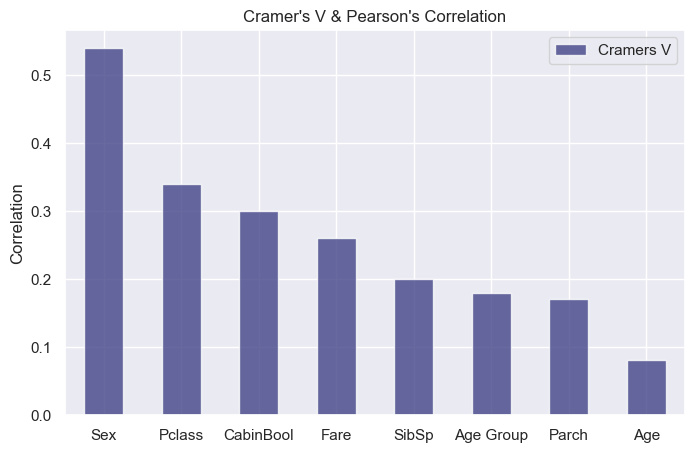

In [63]:
cramers_v_results = {
                        "Age" : 0.08,
                        "Pclass" : 0.34,
                        "Fare" : 0.26,
                        "Sex" : 0.54,
                        "SibSp" : 0.2,
                        "Parch" : 0.17,
                        "Age Group" : 0.18,
                        "CabinBool" : 0.3
}
cramers_v_df = pd.DataFrame.from_dict(cramers_v_results, orient='index', columns=["Cramers V"])
cramers_v_df = cramers_v_df.sort_values(by='Cramers V', ascending=False)

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(cramers_v_df)))  
ax = cramers_v_df.plot(
    kind="bar",
    color=colors,
    alpha=0.8,
    figsize=(8, 5),
    rot=0
)

plt.title("Cramer's V & Pearson's Correlation")
plt.ylabel('Correlation')

---

## Multi-Variate Classification Tree

Response Variable : **Survived**     
Predictor Variables : **Pclass, Sex, SibSp, Parch, Fare, Age Group, CabinBool**    

Extract the variables and the associated data as a Pandas `DataFrame`.

In [64]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [65]:
Y = pd.DataFrame(data["Survived"])
X = pd.DataFrame(data[["Pclass", "Sex", "SibSp", "Parch", "Fare", "Age Group","CabinBool"]])
X.head()

,Pclass,Sex,SibSp,Parch,Fare,Age Group,CabinBool
0,3,male,1,0,7.2500,Student,0
1,1,female,1,0,71.2833,Adult,1
2,3,female,0,0,7.9250,Young Adult,0
3,1,female,1,0,53.1000,Young Adult,1
4,3,male,0,0,8.0500,Young Adult,0


In [66]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
X['Sex'] = label_encoder.fit_transform(X['Sex'])             # fit_transform() Changes (female/male) in 'Sex' column to (0/1)
X['Age Group'] = label_encoder.fit_transform(X['Age Group']) # fit_transform() Changes age groups in 'Age Group' column to (0/1/2.../8)

In [67]:
X.head()

,Pclass,Sex,SibSp,Parch,Fare,Age Group,CabinBool
0,3,1,1,0,7.2500,4,0
1,1,0,1,0,71.2833,0,1
2,3,0,0,0,7.9250,7,0
3,1,0,1,0,53.1000,7,1
4,3,1,0,0,8.0500,7,0


In [68]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25) # Randomiser

print("Train Set :", Y_train.shape, X_train.shape)
print("Test Set  :", Y_test.shape, X_test.shape)

Train Set : (668, 1) (668, 7)
Test Set  : (223, 1) (223, 7)


In [69]:
dectree = DecisionTreeClassifier(max_depth = 10)  # create the decision tree object
dectree.fit(X_train, Y_train)                    # train the decision tree model

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [70]:
import graphviz as gp
#print package version
print("Graphviz version = "+gp.__version__)

Graphviz version = 0.21


In [71]:
from sklearn.tree import export_graphviz
import graphviz

treedot = export_graphviz(dectree,                                      # the model
                          feature_names = X_train.columns.tolist(),              # the features 
                          out_file = None,                              # output file
                          filled = True,                                # node colors
                          rounded = True,                               # make pretty
                          special_characters = True)                    # postscript

graph = graphviz.Source(treedot)

In [72]:
from IPython.display import SVG, display, HTML

# Save as SVG
graph.render("decision_tree", format="svg", cleanup=True)

# Display Scrollable SVG
display(HTML("""
<div style="width:100%; height:600px; overflow:auto; border:1px solid #ccc;">
    <img src="decision_tree.svg">
</div>
"""))

For a better view: Access it from the HTML that is in the same folder as Main.ipynb <br>
HTML File: Only appears after running the above cells
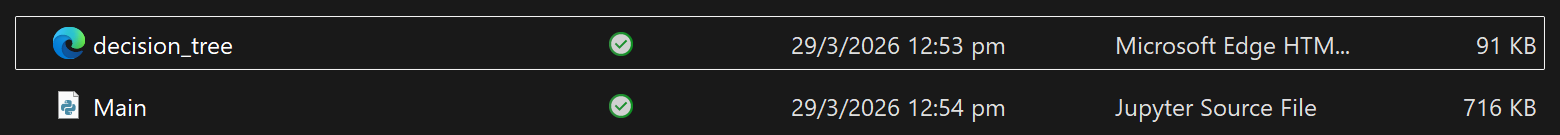

---
### Prediction & Goodness of Fit of Classification Decision Tree

Goodness of Fit of Model 	Train Dataset
Classification Accuracy 	: 0.9266467065868264

Goodness of Fit of Model 	Test Dataset
Classification Accuracy 	: 0.7713004484304933



Text(0.5, 1.0, 'Test Dataset')

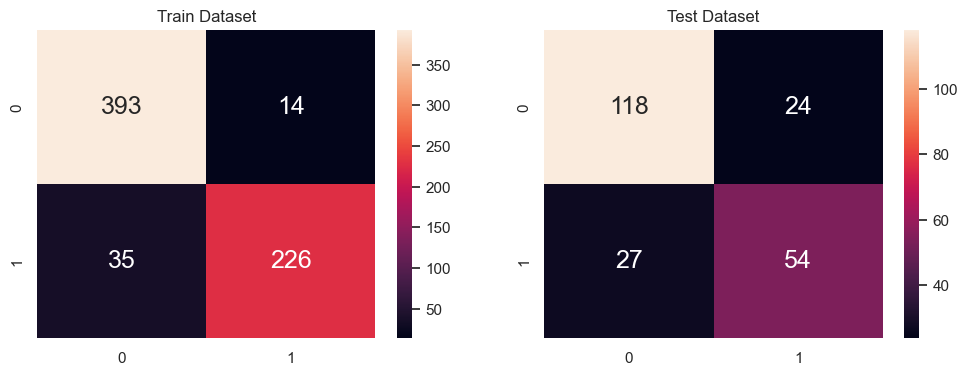

In [73]:
Y_train_pred = dectree.predict(X_train)
Y_test_pred = dectree.predict(X_test)
a = dectree.score(X_train, Y_train)

# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Classification Accuracy \t:", dectree.score(X_train, Y_train))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Classification Accuracy \t:", dectree.score(X_test, Y_test))
print()

# Plot the Confusion Matrix for Train and Test
from sklearn.metrics import confusion_matrix
f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(Y_train, Y_train_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0])
axes[0].set_title("Train Dataset")
sb.heatmap(confusion_matrix(Y_test, Y_test_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1])
axes[1].set_title("Test Dataset")

<div style="display: inline-block">

| |Train Dataset|Test Dataset|
|-|-------------|-------------|
|Classification Accuracy|~90%|~78%|
</div>

### **Explanation**

Model Evaluation (Accuracy vs. Confusion): Corresponds to the "Goodness of Fit of the Model"
- **Classification Accuracy**: The % of correct answers. 
- **Confusion Matrix**: A grid that shows *where* the model makes mistakes.
- It distinguishes between False Positives (Predict 1 when 0) and False Negatives (Predict 0 when 1).

#### Conclusion: The Classification Decision Tree has around 80% of predicting correctly
#### This shows that the tree has a high chance of predicting which passenger will survive or pass on correctly.

---
### Gradient Boosting Classifier
**Function**: Combine many simple decision trees to make better predictions than a single tree could make alone. <br>
`gbk model` : New Gradient Boosting Classifier model <br>
`gbk.fit()` : Trains using `X_Train` and `Y_train.squeeze()` <br>
`.squeeze()`: Converts a column vector to a 1D array <br>

Since there are multiple decision trees instead of a single tree, it is impossible to visualise gbk so we visualise the results instead.


In [74]:
# Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

gbk = GradientBoostingClassifier()
gbk.fit(X_train, Y_train.squeeze())

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


Goodness of Fit of Model 	Train Dataset
Classification Accuracy 	: 0.9011976047904192

Goodness of Fit of Model 	Test Dataset
Classification Accuracy 	: 0.820627802690583



Text(0.5, 1.0, 'Test Dataset')

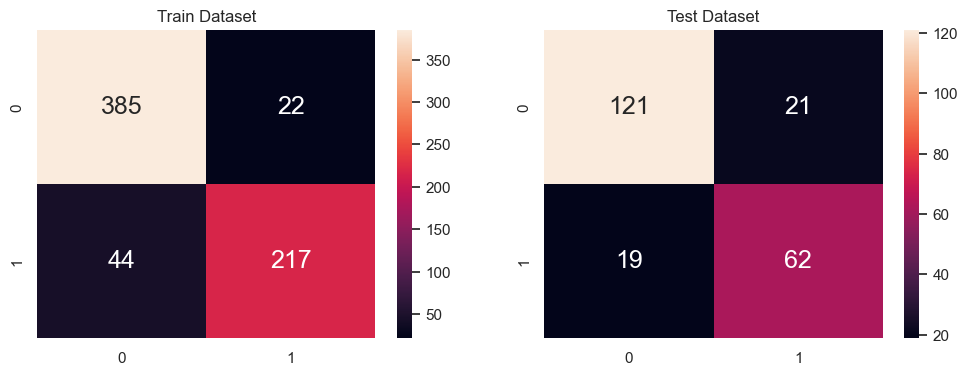

In [75]:
Y_train_pred = gbk.predict(X_train)
Y_test_pred = gbk.predict(X_test)

# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Classification Accuracy \t:", gbk.score(X_train, Y_train))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Classification Accuracy \t:", gbk.score(X_test, Y_test))
print()

# Plot the Confusion Matrix for Train and Test
f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(Y_train, Y_train_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0])
axes[0].set_title("Train Dataset")
sb.heatmap(confusion_matrix(Y_test, Y_test_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1])
axes[1].set_title("Test Dataset")

<div style="display: inline-block">

| |Train Dataset|Test Dataset|
|-|-------------|-------------|
|Classification Accuracy|~89%|~80%|
</div>

---
### GridSearchCV + Gradient Boosting Classifier
Find the best combination of parameters that result in the highest model performance <br>
`n_estimators` : Controls the number sequential trees used <br>
`learning_rate` : Shrinks the contribution of each tree, preventing overfitting <br>
`max_depth` : Limits how deep each tree can grow <br>
`cv=5` : Divides Train Data into 5 parts, Using each part as validation set once <br>
`n_jobs=-1` : Uses all CPU Cores to parallelize the search, Speeding up computation <br>
`.best_params_` : Best Parameters of n_estimators, learning_rate, max_depth <br>
`.best_estimator_` : Model with Best Parameters <br>

In [76]:
# Fine-tuning parameter using GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2, 0.4],
    'max_depth': [3, 5, 7, 9],
}

grid_search = GridSearchCV(estimator=gbk, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train, Y_train.squeeze())

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

Y_pred_best = best_model.predict(X_test)

accuracy_best = accuracy_score(Y_test, Y_pred_best)

print("Best Parameters:", best_params)
print(f"Best Model Accuracy: {accuracy_best}")

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best Model Accuracy: 0.820627802690583


In [77]:
# Fit again using the Best Params
gbk = GradientBoostingClassifier(learning_rate = 0.1, max_depth = 3, n_estimators = 200)
gbk.fit(X_train, Y_train.squeeze())

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


Goodness of Fit of Model 	Train Dataset
Classification Accuracy 	: 0.9296407185628742

Goodness of Fit of Model 	Test Dataset
Classification Accuracy 	: 0.8385650224215246



Text(0.5, 1.0, 'Test Dataset')

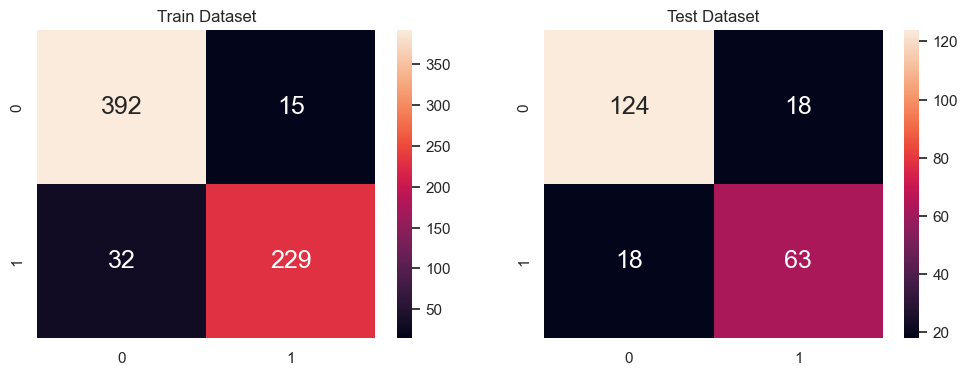

In [78]:
Y_train_pred = gbk.predict(X_train)
Y_test_pred = gbk.predict(X_test)

# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Classification Accuracy \t:", gbk.score(X_train, Y_train))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Classification Accuracy \t:", gbk.score(X_test, Y_test))
print()

# Plot the Confusion Matrix for Train and Test
f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(Y_train, Y_train_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0])
axes[0].set_title("Train Dataset")
sb.heatmap(confusion_matrix(Y_test, Y_test_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1])
axes[1].set_title("Test Dataset")

<div style="display: inline-block">

| |Train Dataset|Test Dataset|
|-|-------------|-------------|
|Classification Accuracy|~92%|~81%|
</div>

### Conclusion: The GridSearchCV + Gradient Boosting Classifier(gbk) has a higher classification accuracy of predicting which passenger will survive or pass on correctly compared to the Classification Decision Tree.

In [79]:
# Check the Goodness of Fit (on Train Data)
print("\033[4m" + "Classification Decision Tree" + "\033[0m")
print("Goodness of Fit of Model \tTrain Dataset")
print("Classification Accuracy \t:", dectree.score(X_train, Y_train))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Classification Accuracy \t:", dectree.score(X_test, Y_test))
print()

# Check the Goodness of Fit (on Train Data)
print("\033[4m" + "GridSearchCV + Gradient Boosting Classifier (gbk)" + "\033[0m")
print("Goodness of Fit of Model \tTrain Dataset")
print("Classification Accuracy \t:", gbk.score(X_train, Y_train))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Classification Accuracy \t:", gbk.score(X_test, Y_test))
print()

Classification Decision Tree
Goodness of Fit of Model 	Train Dataset
Classification Accuracy 	: 0.9266467065868264

Goodness of Fit of Model 	Test Dataset
Classification Accuracy 	: 0.7713004484304933

GridSearchCV + Gradient Boosting Classifier (gbk)
Goodness of Fit of Model 	Train Dataset
Classification Accuracy 	: 0.9296407185628742

Goodness of Fit of Model 	Test Dataset
Classification Accuracy 	: 0.8385650224215246



---
### Shap Explainer
**Function**: Indicate the importance of each Predictor Variables within Gradient Boosting Classifier Model <br>
`shap.Explainer(gbk)`: Creates a Shap explainer object of gbk <br>
`explainer(X)`: Calculate the Shap values for each Predictor Variables <br>
`shape.summary_plot`: Plot the importance of each parameter within the model <br>

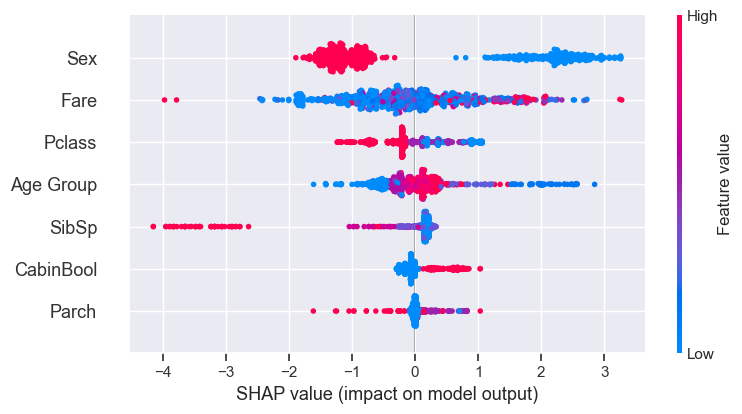

In [80]:
# Explain the importance of each parameter in the model
import shap

explainer = shap.Explainer(gbk)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)

This one help you to understand the impact of each parameter.
- The top one is the most important
- Each dot is one data point
- The dot on the right increases survivability
- Red is high value, blue is low value
- For example, in Sex, blue is all on the right, which is equivalent to female (value 0), increasing survivability and vice versa

---
## Save GridSearchCV + Gradient Boosting Classifier (gbk) Model into a file
#### **Function**: Use the model for App.py

In [81]:
import joblib ##dumping (saving) the model into the folder for future use 
joblib.dump(gbk, "titanic_model.pkl")

['titanic_model.pkl']

---
## Code To Run App.py

In [ ]:
!streamlit run app.py

To Restart App:
Go `Kernel` &rarr; "Restart Kernel and Run All Cells"

---
### App View
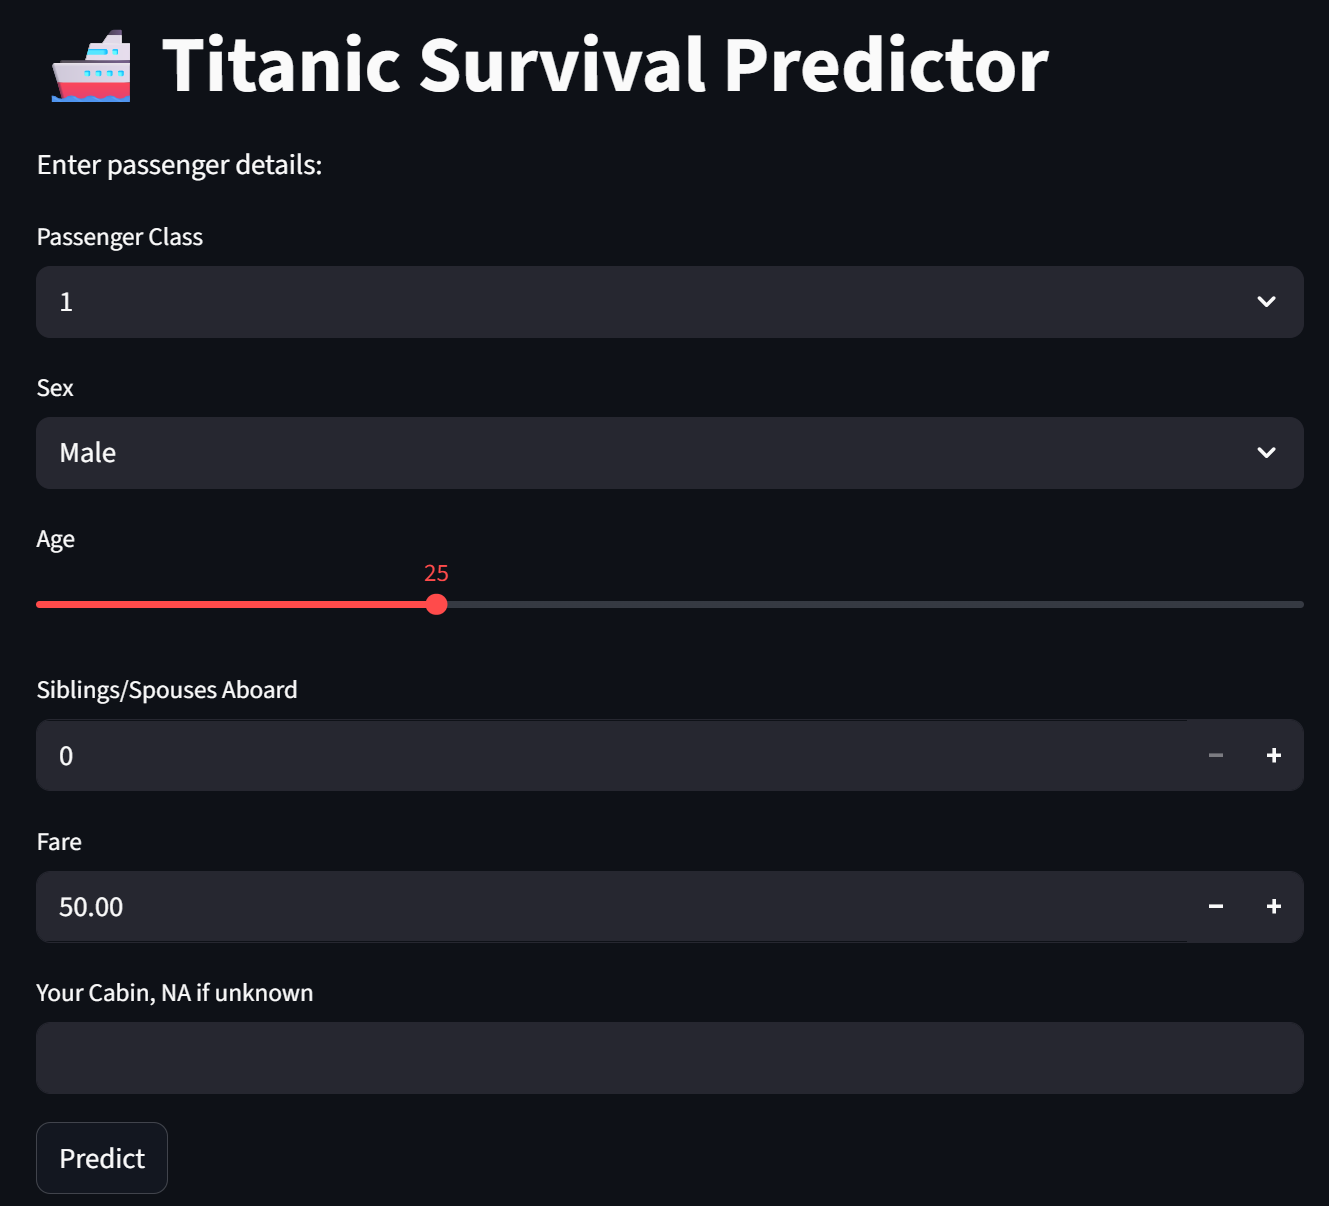

Passenger Class: Has a Drop Down menu to pick your Ticket Class (1/2/3) <br>

Sex: Male/Female <br>

Age: Has a Slider to indicate your Age <br>

Siblings/Spouses: 
- Has "+" and "-" to increase/decrease your number of Siblings/Spouses Aboard
- Can be typed
- Value can not be lesser than 0 <br>

Parents/Children: 
- Has "+" and "-" to increase/decrease your number of Parents/Children Aboard
- Can be typed
- Value can not be lesser than 0 <br>

Fare:
- Has "+" and "-" to increase/decrease your Fare
- Can be typed
- Value can not be lesser than 0 <br>

Cabin:
- Can be typed
- If blank = NA

`Predict`: To Predict your Survivability based on your inputs
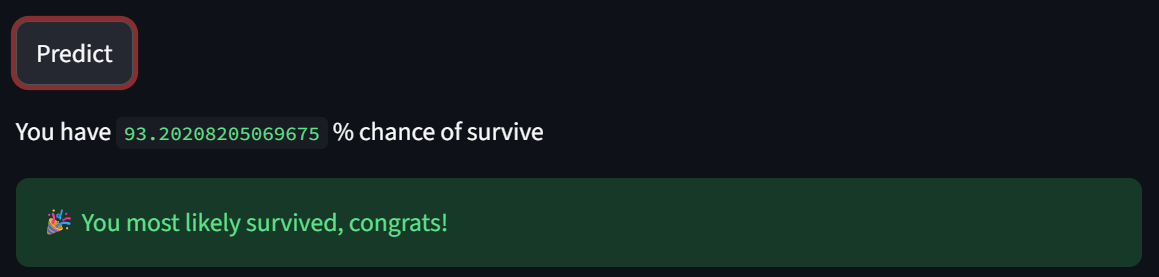